# Пересборка датасета: GPT-2 (50K токенов) → BPE (≤1200 токенов)

Скрипт выполняет 5 шагов:
1. Читает все `.pkl` из датасета, декодирует `input_ids` → текст через GPT-2
2. Собирает обучающий корпус из этих текстов
3. Обучает BPE-токенизатор (`tokenizers`, HuggingFace) на корпусе
4. Пересохраняет `.pkl` с новыми `input_ids` (кадры не меняются)
5. Обновляет конфиг модели (`vocab_size`)

**Входные данные:** оригинальный датасет (`.pkl`-файлы)  
**Выходные данные:** новый датасет в отдельной папке + новый конфиг модели

## Параметры

In [1]:
from pathlib import Path

# ── Пути ──
SRC_DATA_PATH  = Path("D:/Datasets/Dataset_720_proc")          # исходный датасет
DST_DATA_PATH  = Path("D:/Datasets/Dataset_720_proc_bpe")      # новый датасет
TOKENIZER_PATH = Path("configs/bpe_tokenizer")                 # куда сохранить токенизатор
SRC_CONFIG     = Path("configs/model_config_v4.json")          # исходный конфиг
DST_CONFIG     = Path("configs/model_config_v5.json")          # новый конфиг

# Все клипы (train + val + test)
ALL_CLIPS = [f"pt{i}" for i in range(1, 16)]  # pt1 – pt15

# ── Параметры нового токенизатора ──
VOCAB_SIZE = 1200   # целевой размер словаря (включая спец-токены)

# Спец-токены нового токенизатора (аналог старых EOS/PAD/BOS)
BOS_TOKEN = "<|bos|>"
EOS_TOKEN = "<|eos|>"
PAD_TOKEN = "<|pad|>"
UNK_TOKEN = "<|unk|>"

print(f"Источник: {SRC_DATA_PATH}")
print(f"Назначение: {DST_DATA_PATH}")
print(f"Целевой vocab_size: {VOCAB_SIZE}")

Источник: D:\Datasets\Dataset_720_proc
Назначение: D:\Datasets\Dataset_720_proc_bpe
Целевой vocab_size: 1200


## Шаг 1. Декодирование текстов из исходных `.pkl`

In [2]:
import pickle
from transformers import AutoTokenizer

gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")

# Собираем все тексты и индексируем файлы
corpus_texts = []          # список строк для обучения токенизатора
file_index   = []          # (pkl_path, decoded_text) — для шага 4

missing_clips = []

for clip_name in sorted(ALL_CLIPS):
    clip_dir = SRC_DATA_PATH / clip_name
    if not clip_dir.exists():
        missing_clips.append(clip_name)
        continue

    pkl_files = sorted(
        clip_dir.glob("*.pkl"),
        key=lambda f: int(f.stem.split("_")[-1])
    )

    for pkl_path in pkl_files:
        with open(pkl_path, "rb") as f:
            data = pickle.load(f)

        text = gpt2_tokenizer.decode(data["input_ids"])
        corpus_texts.append(text)
        file_index.append((pkl_path, text))

print(f"Файлов найдено:  {len(file_index)}")
print(f"Клипов пропущено: {missing_clips}")
print()
print("=== Примеры текстов ===")
for t in corpus_texts[:5]:
    print(repr(t))

Файлов найдено:  861
Клипов пропущено: ['pt10']

=== Примеры текстов ===
'Hello and a very warm welcome to BBC'
'London. Coming up tonight,'
'Good evening to you. We start tonight'
"with one woman's shocking story. A"
'musician who contacted us about a man'


## Шаг 2. Анализ корпуса

In [3]:
from collections import Counter
import re

all_text = " ".join(corpus_texts)
words    = re.findall(r"\b\w+\b", all_text.lower())
word_freq = Counter(words)

print(f"Всего символов в корпусе:   {len(all_text):,}")
print(f"Всего слов (с повторами):   {len(words):,}")
print(f"Уникальных слов:            {len(word_freq):,}")
print(f"Уникальных символов:        {len(set(all_text)):,}")
print()
print("Топ-30 слов:")
for word, cnt in word_freq.most_common(30):
    print(f"  {word!r:20s} {cnt}")

Всего символов в корпусе:   31,487
Всего слов (с повторами):   5,683
Уникальных слов:            1,613
Уникальных символов:        75

Топ-30 слов:
  'the'                282
  'to'                 165
  'and'                145
  'a'                  135
  's'                  116
  'of'                 104
  'in'                 100
  'london'             77
  'for'                75
  'on'                 69
  'you'                60
  'with'               60
  'it'                 57
  'is'                 51
  'has'                51
  'been'               50
  'from'               48
  'that'               47
  'our'                45
  'more'               43
  'this'               40
  'now'                40
  'bbc'                37
  'at'                 36
  'evening'            35
  'have'               30
  'who'                26
  'as'                 26
  'here'               26
  'we'                 23


## Шаг 3. Обучение BPE-токенизатора

In [4]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing

# Инициализируем BPE-токенизатор
tokenizer = Tokenizer(BPE(unk_token=UNK_TOKEN))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=[PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN],
    min_frequency=1,
    show_progress=True,
)

# Обучаем прямо на строках (не нужен файл)
tokenizer.train_from_iterator(corpus_texts, trainer=trainer)

# Получаем ID спец-токенов
PAD_TOKEN_ID = tokenizer.token_to_id(PAD_TOKEN)
BOS_TOKEN_ID = tokenizer.token_to_id(BOS_TOKEN)
EOS_TOKEN_ID = tokenizer.token_to_id(EOS_TOKEN)

actual_vocab = tokenizer.get_vocab_size()

print(f"Обучение завершено.")
print(f"Реальный vocab_size: {actual_vocab}")
print(f"  PAD={PAD_TOKEN_ID}, BOS={BOS_TOKEN_ID}, EOS={EOS_TOKEN_ID}")

# Проверка на примере
example = corpus_texts[0]
enc = tokenizer.encode(example)
print(f"\nПример: {repr(example[:80])}")
print(f"Токены: {enc.ids}")
print(f"Слова:  {enc.tokens}")

Обучение завершено.
Реальный vocab_size: 1200
  PAD=0, BOS=1, EOS=2

Пример: 'Hello and a very warm welcome to BBC'
Токены: [799, 97, 50, 270, 1195, 1197, 89, 169]
Слова:  ['Hello', 'and', 'a', 'very', 'warm', 'welcome', 'to', 'BBC']


In [5]:
# Сохраняем токенизатор
TOKENIZER_PATH.mkdir(parents=True, exist_ok=True)
tokenizer.save(str(TOKENIZER_PATH / "tokenizer.json"))
print(f"Токенизатор сохранён в {TOKENIZER_PATH / 'tokenizer.json'}")

Токенизатор сохранён в configs\bpe_tokenizer\tokenizer.json


### Статистика токенизации нового словаря

Длина последовательности токенов (по файлам):
  min:    1
  max:    21
  median: 10
  mean:   10.4

Файлов с длиной ≤ 11 токенов (вмещаются без скользящего окна): 569/861 (66.1%)


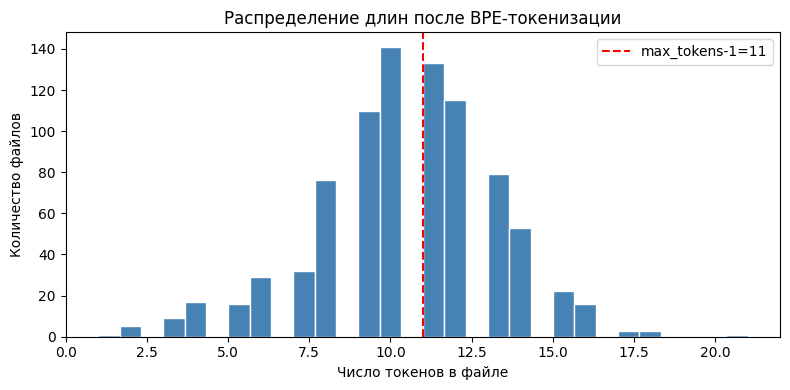

In [6]:
import numpy as np
import matplotlib.pyplot as plt

token_lengths = [len(tokenizer.encode(t).ids) for t in corpus_texts]

print(f"Длина последовательности токенов (по файлам):")
print(f"  min:    {min(token_lengths)}")
print(f"  max:    {max(token_lengths)}")
print(f"  median: {int(np.median(token_lengths))}")
print(f"  mean:   {np.mean(token_lengths):.1f}")
print()

# Сколько файлов вписывается в текущее окно 11 токенов
content_window = 11  # MAX_TOKENS - 1 (без BOS)
fits = sum(1 for l in token_lengths if l <= content_window)
print(f"Файлов с длиной ≤ {content_window} токенов (вмещаются без скользящего окна): "
      f"{fits}/{len(token_lengths)} ({100*fits/len(token_lengths):.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(token_lengths, bins=30, color="steelblue", edgecolor="white")
plt.axvline(content_window, color="red", linestyle="--", label=f"max_tokens-1={content_window}")
plt.xlabel("Число токенов в файле")
plt.ylabel("Количество файлов")
plt.title("Распределение длин после BPE-токенизации")
plt.legend()
plt.tight_layout()
plt.savefig("token_length_distribution.png", dpi=150)
plt.show()

## Шаг 4. Пересохранение `.pkl` с новыми `input_ids`

In [7]:
converted = 0
skipped   = 0

for pkl_src, text in file_index:
    # Зеркальный путь в новом датасете
    rel      = pkl_src.relative_to(SRC_DATA_PATH)
    pkl_dst  = DST_DATA_PATH / rel
    pkl_dst.parent.mkdir(parents=True, exist_ok=True)

    with open(pkl_src, "rb") as f:
        data = pickle.load(f)

    new_ids = tokenizer.encode(text).ids
    if len(new_ids) == 0:
        print(f"[!] Пустая токенизация для {pkl_src.name}, пропуск")
        skipped += 1
        continue

    # Обновляем только input_ids — кадры и num_frames не трогаем
    data["input_ids"] = new_ids

    with open(pkl_dst, "wb") as f:
        pickle.dump(data, f)

    converted += 1

print(f"Конвертировано: {converted} файлов")
print(f"Пропущено:      {skipped} файлов")
print(f"Новый датасет:  {DST_DATA_PATH}")

Конвертировано: 861 файлов
Пропущено:      0 файлов
Новый датасет:  D:\Datasets\Dataset_720_proc_bpe


## Шаг 5. Обновление конфига модели

In [8]:
import json

with open(SRC_CONFIG, "r", encoding="utf-8") as f:
    config = json.load(f)

old_vocab = config["vocab_size"]
config["vocab_size"] = actual_vocab

with open(DST_CONFIG, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"Конфиг сохранён: {DST_CONFIG}")
print(f"  vocab_size: {old_vocab} → {actual_vocab}")
print()
print(json.dumps(config, indent=2, ensure_ascii=False))

Конфиг сохранён: configs\model_config_v5.json
  vocab_size: 50259 → 1200

{
  "vocab_size": 1200,
  "d_model": 64,
  "nhead": 8,
  "num_layers": 4,
  "dim_feedforward": 32,
  "dropout": 0.4,
  "max_frames": 40,
  "max_tokens": 12,
  "encoder": {
    "cnn_frontend": {
      "conv3d": {
        "in_channels": 3,
        "out_channels": 8,
        "kernel_size": [
          3,
          3,
          3
        ],
        "stride": [
          1,
          2,
          2
        ],
        "padding": [
          1,
          1,
          1
        ]
      },
      "maxpool3d": {
        "kernel_size": [
          1,
          3,
          3
        ],
        "stride": [
          1,
          2,
          2
        ],
        "padding": [
          0,
          1,
          1
        ]
      }
    },
    "cnn_backbone": [
      {
        "in_channels": 8,
        "out_channels": 12,
        "kernel_size": 3,
        "stride": 2,
        "padding": 1
      }
    ]
  }
}


## Проверка: загрузка нового датасета

In [9]:
import torch

# Загружаем первый конвертированный файл
sample_pkl = next((DST_DATA_PATH / "pt1").glob("*.pkl"))

with open(sample_pkl, "rb") as f:
    sample = pickle.load(f)

ids   = sample["input_ids"]
text  = tokenizer.decode(ids)

print(f"Файл:        {sample_pkl.name}")
print(f"num_frames:  {sample['num_frames']}")
print(f"input_ids:   {ids}")
print(f"Декодировано: {repr(text)}")
print(f"Кадры shape: {sample['frames'][0].shape}")

Файл:        pt1_0.pkl
num_frames:  50
input_ids:   [799, 97, 50, 270, 1195, 1197, 89, 169]
Декодировано: 'Hello and a very warm welcome to BBC'
Кадры shape: (64, 96, 3)


In [10]:
# Проверка совместимости с Dataset из train.ipynb
# (копируем определение класса без изменений, только DATA_PATH и спец-токены)
import sys
sys.path.insert(0, ".")
from model import load_config

NEW_CONFIG    = load_config(DST_CONFIG)
NEW_PAD_ID    = PAD_TOKEN_ID
NEW_BOS_ID    = BOS_TOKEN_ID
NEW_EOS_ID    = EOS_TOKEN_ID
NEW_VOCAB     = NEW_CONFIG["vocab_size"]
MAX_FRAMES_   = NEW_CONFIG["max_frames"]
MAX_TOKENS_   = NEW_CONFIG["max_tokens"]

print(f"Конфиг загружен: vocab_size={NEW_VOCAB}, max_frames={MAX_FRAMES_}, max_tokens={MAX_TOKENS_}")
print(f"Спец-токены: PAD={NEW_PAD_ID}, BOS={NEW_BOS_ID}, EOS={NEW_EOS_ID}")
print()

# Быстрый подсчёт сэмплов
FRAME_STRIDE_   = 10
TOKEN_CONTENT_  = MAX_TOKENS_ - 1
TOKEN_STRIDE_   = 3

TRAIN_CLIPS_ = [f"pt{i}" for i in range(1, 12)]
VAL_CLIPS_   = [f"pt{i}" for i in range(12, 14)]
TEST_CLIPS_  = [f"pt{i}" for i in range(14, 16)]

def count_samples(data_path, clip_names, max_frames, frame_stride, token_content, token_stride):
    total = 0
    for clip_name in clip_names:
        clip_dir = data_path / clip_name
        if not clip_dir.exists():
            continue
        for pkl_path in clip_dir.glob("*.pkl"):
            with open(pkl_path, "rb") as f:
                d = pickle.load(f)
            nf = d["num_frames"]
            nt = len(d["input_ids"])
            if nf <= max_frames:
                total += 1
            else:
                fs = 0
                ts = 0
                while fs + max_frames <= nf:
                    te = min(ts + token_content, nt)
                    if te > ts:
                        total += 1
                    fs += frame_stride
                    ts += token_stride
    return total

n_train = count_samples(DST_DATA_PATH, TRAIN_CLIPS_, MAX_FRAMES_, FRAME_STRIDE_, TOKEN_CONTENT_, TOKEN_STRIDE_)
n_val   = count_samples(DST_DATA_PATH, VAL_CLIPS_,   MAX_FRAMES_, FRAME_STRIDE_, TOKEN_CONTENT_, TOKEN_STRIDE_)
n_test  = count_samples(DST_DATA_PATH, TEST_CLIPS_,  MAX_FRAMES_, FRAME_STRIDE_, TOKEN_CONTENT_, TOKEN_STRIDE_)

print(f"Сэмплов в новом датасете:")
print(f"  Train: {n_train}")
print(f"  Val:   {n_val}")
print(f"  Test:  {n_test}")

Конфиг загружен: vocab_size=1200, max_frames=40, max_tokens=12
Спец-токены: PAD=0, BOS=1, EOS=2

Сэмплов в новом датасете:
  Train: 996
  Val:   334
  Test:  316


## Итог

После выполнения всех шагов:

- Новый датасет: `DST_DATA_PATH` (`.pkl`-файлы с новыми `input_ids`)
- Токенизатор:   `configs/bpe_tokenizer/tokenizer.json`
- Конфиг модели: `configs/model_config_v5.json` (`vocab_size` обновлён)

**Что изменить в `train.ipynb` для запуска обучения:**
```python
# Вместо:
DATA_PATH        = "D:/Datasets/Dataset_720_proc"
MODEL_CONFIG_PATH = "configs/model_config_v4.json"
EOS_TOKEN_ID = 50256
PAD_TOKEN_ID = 50257
BOS_TOKEN_ID = 50258

# Поставить:
from tokenizers import Tokenizer
DATA_PATH        = "D:/Datasets/Dataset_720_proc_bpe"
MODEL_CONFIG_PATH = "configs/model_config_v5.json"
bpe = Tokenizer.from_file("configs/bpe_tokenizer/tokenizer.json")
PAD_TOKEN_ID = bpe.token_to_id("<|pad|>")
BOS_TOKEN_ID = bpe.token_to_id("<|bos|>")
EOS_TOKEN_ID = bpe.token_to_id("<|eos|>")
```